## Imports

In [1]:
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


d:\Tisya\projects\AYUSH\venv\Scripts\python.exe


## Load the data

In [2]:
train = pd.read_csv(
    "../data/processed/FD001/train_FD001_clean.csv"
)

print("Shape:", train.shape)
display(train.head())

train_fe = train.copy()

max_cycles = train_fe.groupby("unit")["cycle"].transform("max")
train_fe["RUL"] = max_cycles - train_fe["cycle"]

print("Shape:", train_fe.shape)
display(train_fe.head())

Shape: (20631, 19)


,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


Shape: (20631, 20)


,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


## Sensor temporal features

In [3]:
temporal_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_9",
    "sensor_12",
    "sensor_7",
    "sensor_14",
    "sensor_15"
]

print("Temporal sensors:")
print(temporal_sensors)

Temporal sensors:
['sensor_11', 'sensor_4', 'sensor_9', 'sensor_12', 'sensor_7', 'sensor_14', 'sensor_15']


In [4]:
train_fe = train_fe.sort_values(
    ["unit", "cycle"]
).copy()

print("Sorted:", train_fe[["unit", "cycle"]].head())

Sorted:    unit  cycle
0     1      1
1     1      2
2     1      3
3     1      4
4     1      5


In [5]:
for sensor in temporal_sensors:
    train_fe[f"{sensor}_diff_1"] = (
        train_fe.groupby("unit")[sensor].diff(1)
    )

diff_columns = [
    f"{sensor}_diff_1"
    for sensor in temporal_sensors
]

print(
    train_fe[diff_columns].isna().sum()
)

sensor_11_diff_1    100
sensor_4_diff_1     100
sensor_9_diff_1     100
sensor_12_diff_1    100
sensor_7_diff_1     100
sensor_14_diff_1    100
sensor_15_diff_1    100
dtype: int64


In [6]:
for sensor in temporal_sensors:
    train_fe[f"{sensor}_rolling_mean_5"] = (
        train_fe.groupby("unit")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
    )

for sensor in temporal_sensors:
    train_fe[f"{sensor}_rolling_std_5"] = (
        train_fe.groupby("unit")[sensor]
        .transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    )

In [7]:
print("Original columns:", train.shape[1])
print("Feature-engineered columns:", train_fe.shape[1])

print("\nNew features:")
new_features = [
    col for col in train_fe.columns
    if col not in train.columns and col!="RUL"
]

print(new_features)
print("\nNumber of new features:", len(new_features))

Original columns: 19
Feature-engineered columns: 41

New features:
['sensor_11_diff_1', 'sensor_4_diff_1', 'sensor_9_diff_1', 'sensor_12_diff_1', 'sensor_7_diff_1', 'sensor_14_diff_1', 'sensor_15_diff_1', 'sensor_11_rolling_mean_5', 'sensor_4_rolling_mean_5', 'sensor_9_rolling_mean_5', 'sensor_12_rolling_mean_5', 'sensor_7_rolling_mean_5', 'sensor_14_rolling_mean_5', 'sensor_15_rolling_mean_5', 'sensor_11_rolling_std_5', 'sensor_4_rolling_std_5', 'sensor_9_rolling_std_5', 'sensor_12_rolling_std_5', 'sensor_7_rolling_std_5', 'sensor_14_rolling_std_5', 'sensor_15_rolling_std_5']

Number of new features: 21


In [8]:
print("Missing values before filling:")
print(train_fe.isna().sum().sort_values(ascending=False).head(10))

Missing values before filling:
sensor_11_rolling_std_5    100
sensor_15_rolling_std_5    100
sensor_15_diff_1           100
sensor_7_rolling_std_5     100
sensor_11_diff_1           100
sensor_7_diff_1            100
sensor_12_diff_1           100
sensor_9_diff_1            100
sensor_4_diff_1            100
sensor_14_rolling_std_5    100
dtype: int64


In [9]:
train_fe[new_features] = train_fe[new_features].fillna(0)

print(
    "Total missing values after filling:",
    train_fe.isna().sum().sum()
)

Total missing values after filling: 0


In [10]:
print("Final shape:", train_fe.shape)
print("Missing values:", train_fe.isna().sum().sum())
print("Number of engines:", train_fe["unit"].nunique())

assert train_fe.shape[0] == train.shape[0]
assert train_fe["unit"].nunique() == 100
assert train_fe.isna().sum().sum() == 0


Final shape: (20631, 41)
Missing values: 0
Number of engines: 100


In [11]:
train_fe.to_csv(
    "../data/processed/FD001/train_FD001_feature_engineered.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/FD001/train_FD001_feature_engineered.csv"
)

Saved: ../data/processed/FD001/train_FD001_feature_engineered.csv


In [12]:
feature_columns_fe = [
    col for col in train_fe.columns
    if col not in ["unit", "RUL"]
]

X_fe = train_fe[feature_columns_fe].copy()
y_fe = train_fe["RUL"].copy()

print("X_fe shape:", X_fe.shape)
print("y_fe shape:", y_fe.shape)
print("Number of features:", len(feature_columns_fe))

X_fe shape: (20631, 39)
y_fe shape: (20631,)
Number of features: 39


In [13]:
engine_ids = train_fe["unit"].unique()

train_units, val_units = train_test_split(
    engine_ids,
    test_size=0.20,
    random_state=42
)

train_mask_fe = train_fe["unit"].isin(train_units)
val_mask_fe = train_fe["unit"].isin(val_units)

X_fe_train = X_fe.loc[train_mask_fe]
y_fe_train = y_fe.loc[train_mask_fe]

X_fe_val = X_fe.loc[val_mask_fe]
y_fe_val = y_fe.loc[val_mask_fe]

print("Training engines:", len(train_units))
print("Validation engines:", len(val_units))
print("X_fe_train:", X_fe_train.shape)
print("y_fe_train:", y_fe_train.shape)
print("X_fe_val:", X_fe_val.shape)
print("y_fe_val:", y_fe_val.shape)
overlap_fe = (
    set(train_fe.loc[train_mask_fe, "unit"])
    & set(train_fe.loc[val_mask_fe, "unit"])
)

print("Overlapping engines:", overlap_fe)

assert len(overlap_fe) == 0

Training engines: 80
Validation engines: 20
X_fe_train: (16561, 39)
y_fe_train: (16561,)
X_fe_val: (4070, 39)
y_fe_val: (4070,)
Overlapping engines: set()


## Training XGBoost on the feature engineered data

In [14]:
xgb_fe_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_fe_model.fit(
    X_fe_train,
    y_fe_train
)

xgb_fe_pred = xgb_fe_model.predict(X_fe_val)

xgb_fe_mae = mean_absolute_error(
    y_fe_val,
    xgb_fe_pred
)

xgb_fe_rmse = np.sqrt(
    mean_squared_error(
        y_fe_val,
        xgb_fe_pred
    )
)

xgb_fe_r2 = r2_score(
    y_fe_val,
    xgb_fe_pred
)

print("Feature-Engineered XGBoost Results")
print("MAE :", round(xgb_fe_mae, 3))
print("RMSE:", round(xgb_fe_rmse, 3))
print("R²  :", round(xgb_fe_r2, 3))

Feature-Engineered XGBoost Results
MAE : 23.778
RMSE: 32.045
R²  : 0.762


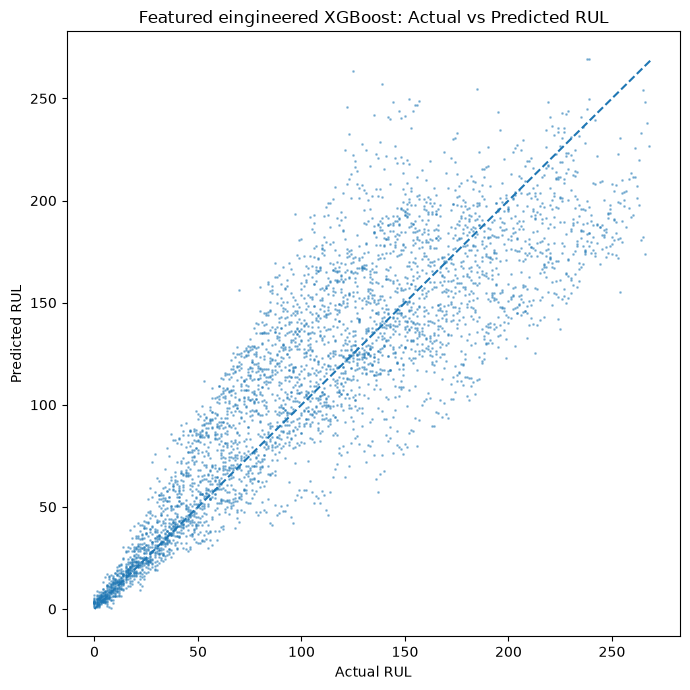

In [15]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_fe_val,
    xgb_fe_pred,
    alpha=0.4,
    s=1
)

min_value = min(y_fe_val.min(), xgb_fe_pred.min())
max_value = max(y_fe_val.max(), xgb_fe_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Featured eingineered XGBoost: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/fe_xgboost/fe_XGBoost_Actual_vs_Predicted_RUL.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


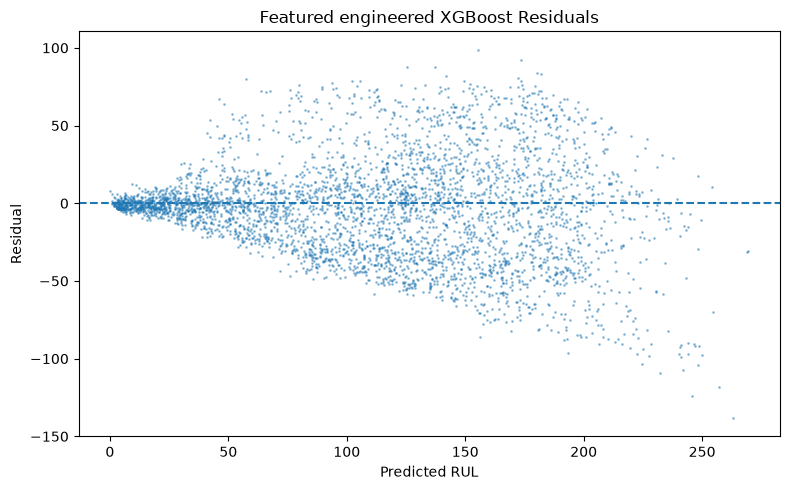

In [16]:
xgb_fe_residuals = y_fe_val - xgb_fe_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    xgb_fe_pred,
    xgb_fe_residuals,
    alpha=0.4,
    s=1
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Featured engineered XGBoost Residuals")

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/fe_xgboost/fe_XGBoost_Residuals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
xgb_fe_results = pd.DataFrame({
    "model": ["XGBoost Feature-Engineered"],
    "MAE": [xgb_fe_mae],
    "RMSE": [xgb_fe_rmse],
    "R2": [xgb_fe_r2]
})

display(xgb_fe_results)

,model,MAE,RMSE,R2
0,XGBoost Feature-Engineered,23.778479,32.044521,0.761761


### compare with the baseline xgboost

In [18]:
comparison =  pd.read_csv(
    "../reports/FD001/baseline_results.csv"
)

In [19]:
XGBoost_Feature_Engineered = comparison.iloc[2].to_frame().T.replace({"model": {"XGBoost": "XGBoost Baseline"}})

fe_comparison = pd.concat(
    [XGBoost_Feature_Engineered, xgb_fe_results],
    ignore_index=True
)

display(fe_comparison)

fe_comparison.to_csv(
    "../reports/FD001/feature_engineering_comparison.csv",
    index=False
)

print("Saved feature engineering comparison.")

,model,MAE,RMSE,R2
0,XGBoost Baseline,23.678049,31.189005,0.774312
1,XGBoost Feature-Engineered,23.778479,32.044521,0.761761


Saved feature engineering comparison.


## Comparison with all the other models

In [20]:
comparison = pd.concat(
    [comparison, xgb_fe_results],
    ignore_index=True
)

display(comparison)

comparison.to_csv(
    "../reports/FD001/model_comparison.csv",
    index=False
)

print("Saved Model Comparison.")

,model,MAE,RMSE,R2
0,Linear Regression,25.155168,31.655955,0.767504
1,Random Forest,23.938742,31.606191,0.768234
2,XGBoost,23.678049,31.189005,0.774312
3,XGBoost Feature-Engineered,23.778479,32.044521,0.761761


Saved Model Comparison.


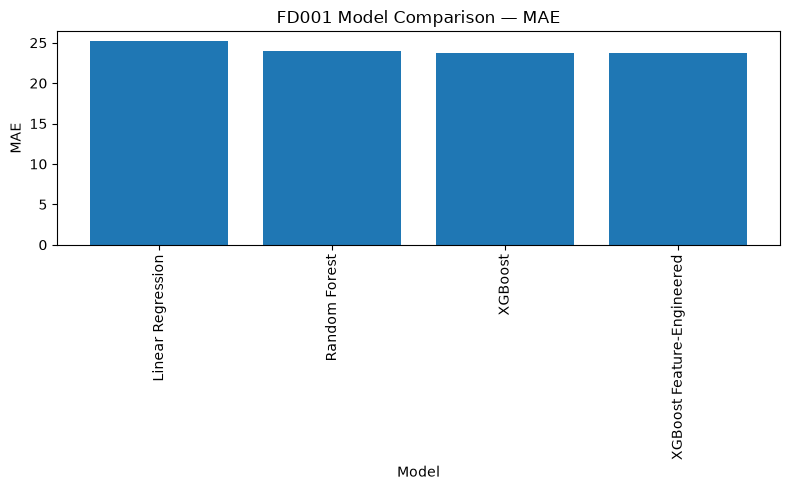

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("FD001 Model Comparison — MAE")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/comparison/FD001_Model_Comparison_MAE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

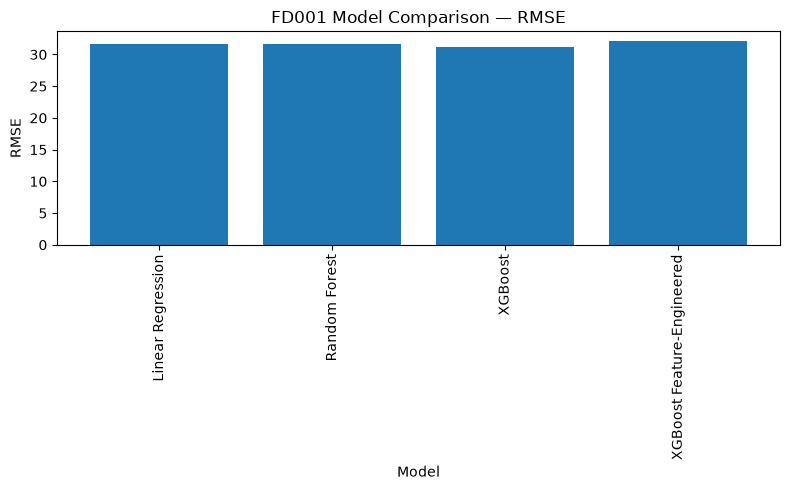

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("FD001 Model Comparison — RMSE")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/FD001/figures/comparison/FD001_Model_Comparison_RMSE.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
best_model_row = comparison.loc[
    comparison["MAE"].idxmin()
]

print("Best validation model:")
print(best_model_row)

Best validation model:
model      XGBoost
MAE      23.678049
RMSE     31.189005
R2        0.774312
Name: 2, dtype: object


XGBoost baseline as the best validation model.